In [2]:
pip install pandas numpy scikit-learn transformers torch shap matplotlib

In [3]:
# Data handling
import pandas as pd
import numpy as np

# Visualization (for later)
import matplotlib.pyplot as plt
import seaborn as sns

# ML models
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix

# BERT
from transformers import BertTokenizer, BertModel
import torch

# Explainability
import shap

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [4]:
# Load dataset
df = pd.read_csv(
    "/content/Suicide_Detection.csv",
    engine='python',
    on_bad_lines='skip'
)
# Drop useless column
df = df.drop(columns=['Unnamed: 0'])

# Rename target column
df = df.rename(columns={'class': 'label'})

# Convert labels to numeric
df['label'] = df['label'].map({
    'suicide': 1,
    'non-suicide': 0
})

# Remove null values
df = df.dropna()

# Check dataset
print("Shape:", df.shape)
print(df['label'].value_counts())

Shape: (232074, 2)
label
1    116037
0    116037
Name: count, dtype: int64


In [5]:
df = df.sample(5000, random_state=42).reset_index(drop=True)

print("New Shape:", df.shape)

New Shape: (5000, 2)


In [6]:
import numpy as np

df['sleep_hours'] = np.random.normal(6, 1.5, len(df))
df['activity_level'] = np.random.uniform(0, 1, len(df))
df['screen_time'] = np.random.normal(5, 2, len(df))

# Adjust for suicidal class
df.loc[df['label'] == 1, 'sleep_hours'] -= 2
df.loc[df['label'] == 1, 'screen_time'] += 2

In [7]:
from transformers import BertTokenizer, BertModel
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased')

bert_model.eval()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BertModel(
  (embeddings): BertEmbeddings(
    (word_embeddings): Embedding(30522, 768, padding_idx=0)
    (position_embeddings): Embedding(512, 768)
    (token_type_embeddings): Embedding(2, 768)
    (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (encoder): BertEncoder(
    (layer): ModuleList(
      (0-11): 12 x BertLayer(
        (attention): BertAttention(
          (self): BertSelfAttention(
            (query): Linear(in_features=768, out_features=768, bias=True)
            (key): Linear(in_features=768, out_features=768, bias=True)
            (value): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (output): BertSelfOutput(
            (dense): Linear(in_features=768, out_features=768, bias=True)
            (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
  

In [8]:
def get_embeddings(texts, batch_size=16):
    embeddings = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(batch, return_tensors='pt',
                           padding=True, truncation=True, max_length=128)

        with torch.no_grad():
            outputs = bert_model(**inputs)

        batch_embeddings = outputs.last_hidden_state.mean(dim=1)
        embeddings.append(batch_embeddings.numpy())

    return np.vstack(embeddings)

In [9]:
texts = df['text'].tolist()

X_text = get_embeddings(texts)

print("BERT Shape:", X_text.shape)

BERT Shape: (5000, 768)


In [10]:
behavior_features = df[['sleep_hours', 'activity_level', 'screen_time']].values

In [11]:
import numpy as np

X = np.hstack([X_text, behavior_features])
y = df['label'].values

print("Final Shape:", X.shape)

Final Shape: (5000, 771)


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

print("Train Accuracy:", model.score(X_train, y_train))
print("Test Accuracy:", model.score(X_test, y_test))

Train Accuracy: 0.98575
Test Accuracy: 0.904


In [13]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(model, X, y, cv=5, scoring='f1_weighted')

print("F1 Score:", scores.mean())

F1 Score: 0.9011475180606139


In [14]:
feature_names = [f"bert_{i}" for i in range(768)] + [
    "sleep_hours", "activity_level", "screen_time"
]

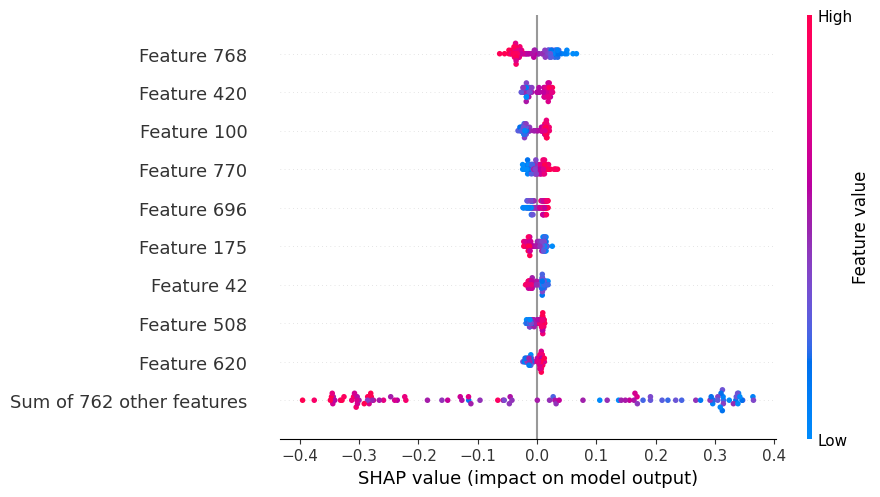

In [15]:
import shap

# Create explainer
explainer = shap.Explainer(model, X_test)

# Generate SHAP values
shap_values = explainer(X_test[:100])

# Select class 1 (suicide class)
shap_class1 = shap_values[:, :, 1]

# Beeswarm plot
shap.plots.beeswarm(shap_class1)

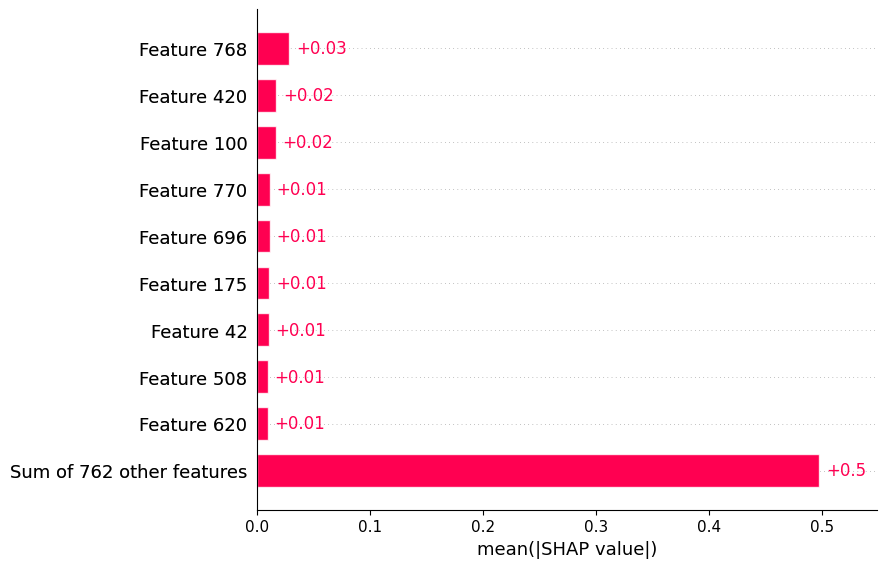

In [16]:
import shap

# Create explainer
explainer = shap.Explainer(model, X_test)

# Generate SHAP values
shap_values = explainer(X_test[:100])

# Select class 1 (suicide class)
shap_class1 = shap_values[:, :, 1]

# Beeswarm plot
shap.plots.bar(shap_class1)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(df['text'])

# Train-test split
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42
)

# Train SVM
svm_model = LinearSVC()
svm_model.fit(X_train_t, y_train_t)

print("Baseline Accuracy:", svm_model.score(X_test_t, y_test_t))

Baseline Accuracy: 0.914


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = model.predict(X_test)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))



Accuracy : 0.904
Precision: 0.9147609147609148
Recall   : 0.8888888888888888
F1 Score : 0.9016393442622951


In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.92      0.91       505
           1       0.91      0.89      0.90       495

    accuracy                           0.90      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.90      0.90      0.90      1000



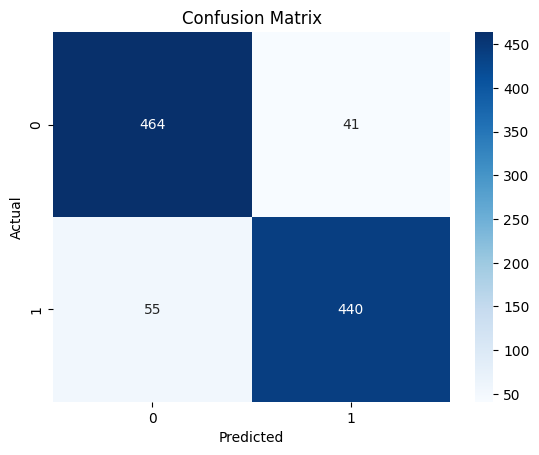

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [21]:
from sklearn.metrics import roc_auc_score

y_probs = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_probs)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9597439743974397


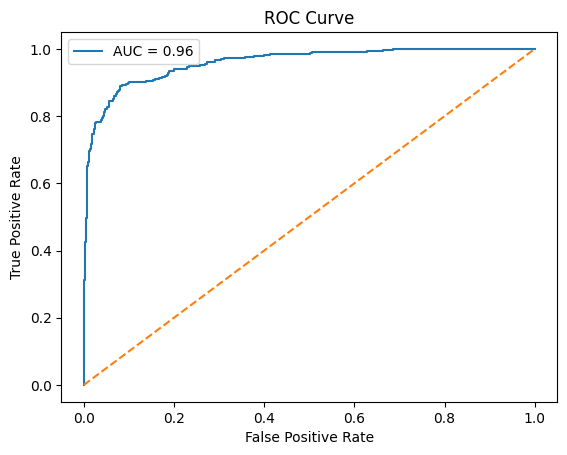

In [22]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_probs)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [23]:
from sklearn.model_selection import cross_val_score

f1_scores = cross_val_score(model, X, y, cv=5, scoring='f1_weighted')
precision_scores = cross_val_score(model, X, y, cv=5, scoring='precision_weighted')
recall_scores = cross_val_score(model, X, y, cv=5, scoring='recall_weighted')

print("F1 (CV):", f1_scores.mean())
print("Precision (CV):", precision_scores.mean())
print("Recall (CV):", recall_scores.mean())

F1 (CV): 0.9011475180606139
Precision (CV): 0.9016869706350349
Recall (CV): 0.9012


In [24]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5)

f1_scores = cross_val_score(model, X, y, cv=skf, scoring='f1_weighted')

print("Stratified F1:", f1_scores.mean())

Stratified F1: 0.9011475180606139
